# [LAB-11] 5. [연습문제] 서울 월평균 기온의 정상성

> **문제**
>
> `temperatures_seoul` 데이터는 1973년 7월 ~ 2023년 8월까지 서울의 월평균 기온을 조사한 자료이다.
> 이 데이터의 **정상성 여부를 확인**하고 **정상성 확보를 위한 데이터 전처리를 수행**하시오.
> 전처리 수행 후 총 몇 번의 변환이 적용되었는지 **$d$, $D$, $s$ 값을 답하시오.**

1~4단원에서 만든 `my_ts` 모듈만으로 푼다.

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data

# 강의용 공용 모듈(my_ts, my_plot, ...)
from helpers import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기

In [2]:
origin = load_data('temperatures_seoul')
origin.head()

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)


,날짜,평균기온(℃)
0,1973-07-01,26.816
1,1973-08-01,25.884
2,1973-09-01,20.323
3,1973-10-01,13.039
4,1973-11-01,4.723


### 3. 시계열 인덱스 설정

`my_ts.set_index()` 로 날짜 컬럼을 인덱스로 지정하고 `freq="MS"` 로 **매월 1일 간격**임을 못 박는다.
간격을 명시해야 뒤에서 쓸 `period=12` 가 "관측치 12개"가 아니라 **"1년"** 을 뜻하게 된다.

In [3]:
df = my_ts.set_index(origin, "날짜", freq="MS")

print(f"기간: {df.index[0]:%Y-%m} ~ {df.index[-1]:%Y-%m} | {len(df)}개월 | 간격 {df.index.freqstr}")
df.head(3)

기간: 1973-07 ~ 2023-08 | 602개월 | 간격 MS


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323


### 4. 데이터의 모습부터 본다

검정 전에 눈으로 확인한다. **추세 · 계절성 · 변동폭** 세 가지를 본다.

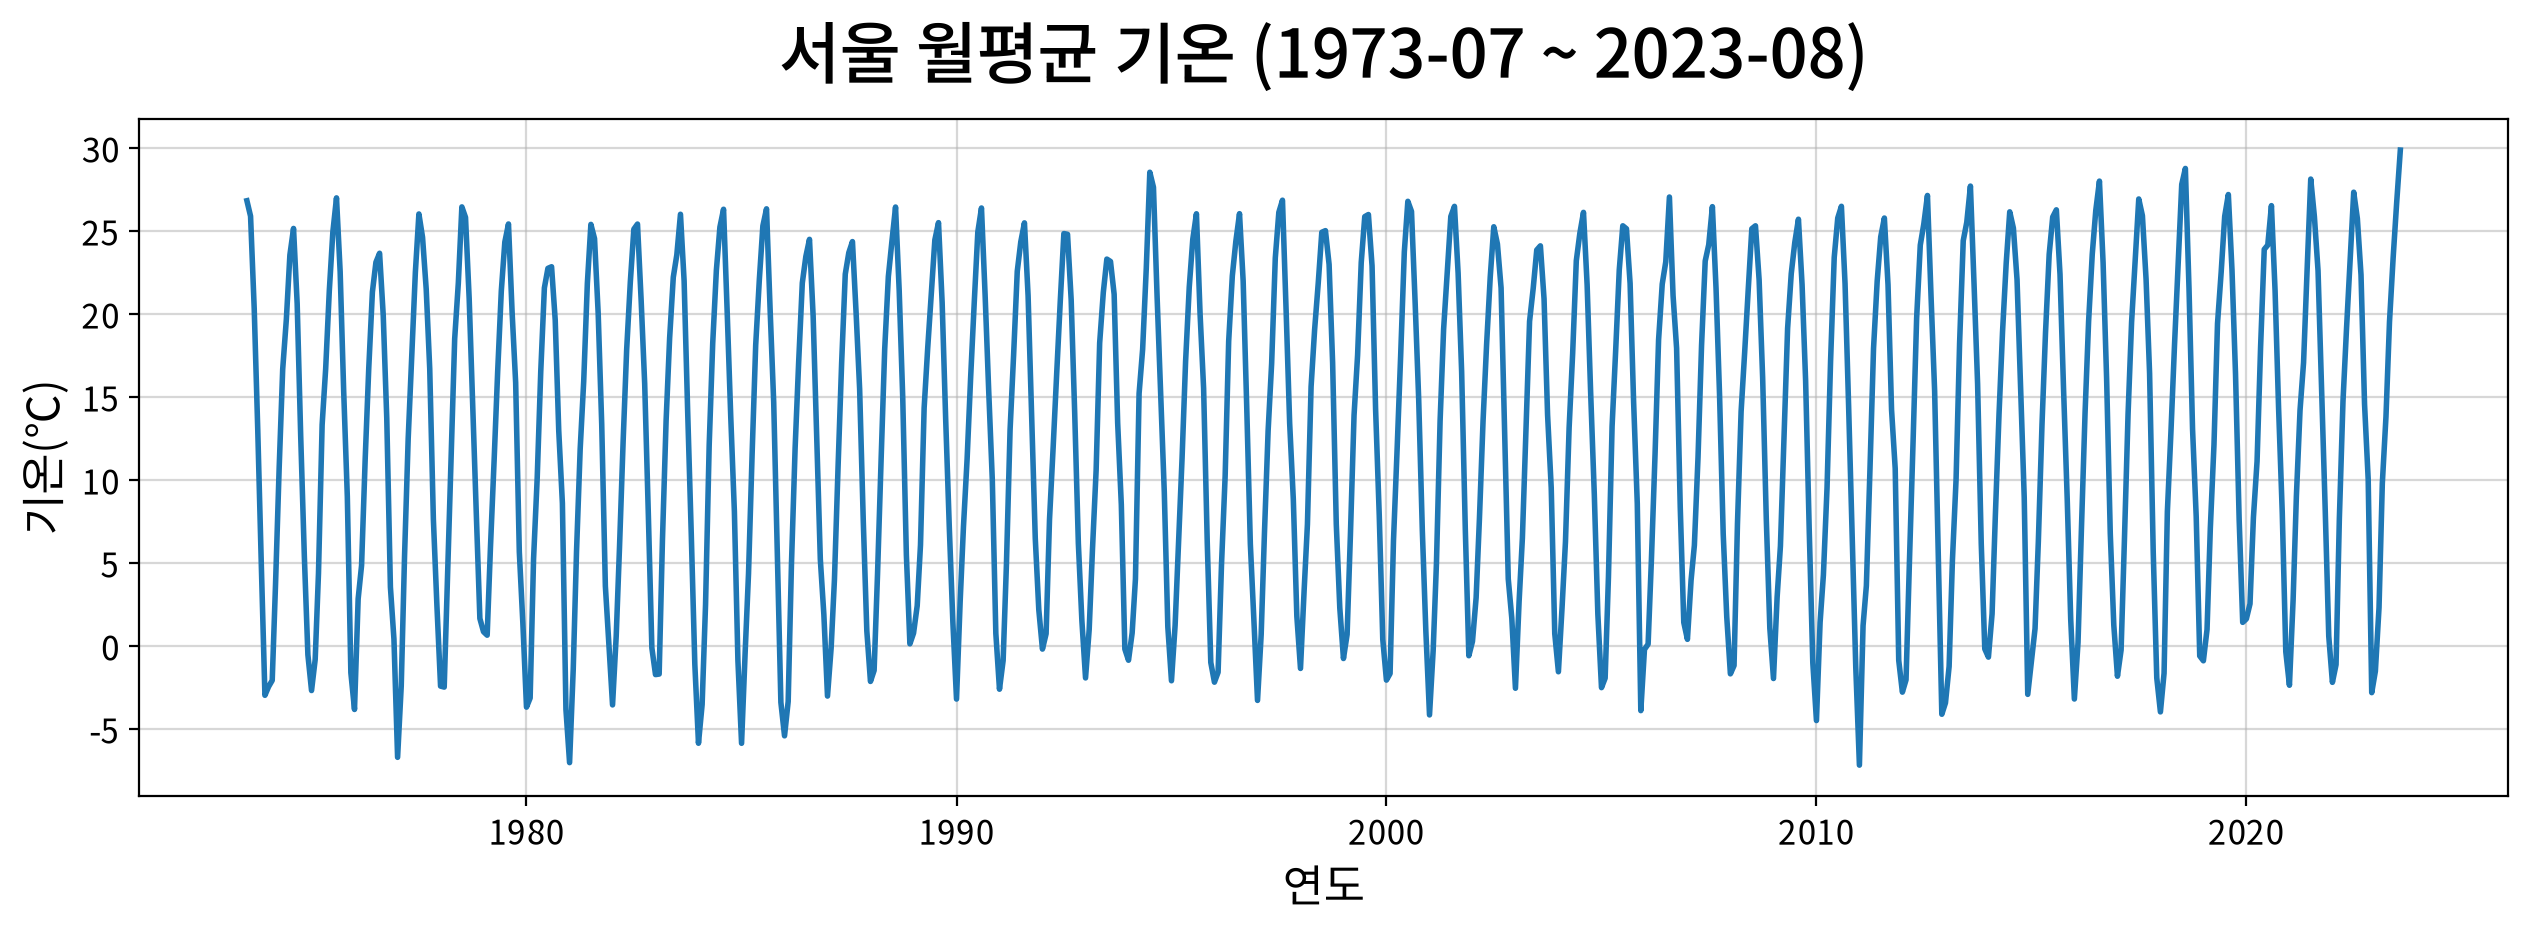

In [4]:
my_plot.lineplot(data=df, x=df.index, y="평균기온(℃)",
                 title="서울 월평균 기온 (1973-07 ~ 2023-08)",
                 xlabel="연도", ylabel="기온(℃)",
                 width=1280, height=480)

#### 💡 인사이트

| 확인 항목 | 관찰 결과 |
|---|---|
| ① 추세 | 뚜렷하지 않다. 50년 내내 비슷한 높이에서 오르내린다 |
| ② 계절성 | **압도적이다.** 매년 같은 모양의 산과 골이 정확히 반복된다 |
| ③ 변동폭 | 처음과 끝의 진폭이 비슷하다. 커지지 않는다 |

> 항공 승객 데이터와 정반대다. 그쪽은 **추세와 변동폭 증가**가 문제였는데,
> 이 데이터는 **계절성 하나**가 지배한다. 기온은 계절 그 자체이니 당연한 결과다.

## #02. 정상성 확인

### 1. 구간을 나눠서 비교

정상성의 정의가 "어느 구간을 잘라도 비슷하다"이므로 실제로 잘라서 비교한다.

In [5]:
my_ts.report_split(df, "평균기온(℃)", size=3)

,시작,종료,관측치 수,평균,표준편차,변동계수
구간,,,,,,
구간 1,1973-07-01,1990-02-01,200,11.849,10.057,0.849
구간 2,1990-03-01,2006-10-01,200,12.973,9.586,0.739
구간 3,2006-11-01,2023-06-01,200,12.864,10.081,0.784


#### 💡 인사이트

| 구간 | 평균 | 표준편차 |
|---|---|---|
| 1973-07 ~ 1990-02 | 11.849 | 10.057 |
| 1990-03 ~ 2006-10 | 12.973 | 9.586 |
| 2006-11 ~ 2023-06 | 12.864 | 10.081 |

- **평균** 11.85 → 12.97 → 12.86. 첫 구간보다 1℃ 정도 오르긴 했지만 **계속 커지지는 않는다.**
- **표준편차** 10.06 → 9.59 → 10.08. 사실상 **변하지 않는다.**

> 항공 데이터는 평균이 158 → 269 → 413, 표준편차가 33 → 56 → 79로 **둘 다 계속 커졌다.**
> 이 데이터는 두 조건이 모두 안정적이다. **적어도 추세와 분산 문제는 없다.**

### 2. 변동폭이 수준에 비례하는가 — 로그변환이 필요한지 판단

In [6]:
my_ts.report_variation(df, "평균기온(℃)")

표준편차 최대/최소: 1.31배
변동계수 최대/최소: 1.43배
판정: 변동폭이 일정하다 → 원본 사용 가능 / 가법(additive) 모델


,평균,표준편차,변동계수
기간,,,
1973-12-31,14.635,11.985,0.819
1974-12-31,11.080,10.135,0.915
1975-12-31,12.456,10.690,0.858
1976-12-31,11.461,9.642,0.841
1977-12-31,12.293,10.949,0.891
1978-12-31,12.362,10.562,0.854
1979-12-31,12.433,9.348,0.752
1980-12-31,10.794,10.327,0.957
1981-12-31,11.158,10.872,0.974


#### 💡 인사이트

**판정: 변동폭이 일정하다 → 원본 사용 가능 / 가법(additive) 모델**

표준편차 최대/최소가 1.31배, 변동계수가 1.43배로 **둘 다 작다.**
항공 데이터의 5.67배와 비교하면 차이가 분명하다. **로그변환이 필요 없다.**

> ⚠️ **애초에 이 데이터에는 로그변환을 쓸 수 없다.**
> 기온에는 **영하** 값이 있다. 0 이하의 수에는 로그를 취할 수 없어 결과가 결측치가 된다.
> 다음 셀에서 실제로 확인한다.

In [7]:
# 0℃ 이하인 달이 몇 개월이나 되는가
below = df[df["평균기온(℃)"] <= 0]

print(f"0℃ 이하: {len(below)}개월 / 전체 {len(df)}개월")
print(f"최저 기온: {df['평균기온(℃)'].min():.2f}℃")

below.head(3)

0℃ 이하: 90개월 / 전체 602개월
최저 기온: -7.18℃


,평균기온(℃)
날짜,
1973-12-01,-2.977
1974-01-01,-2.458
1974-02-01,-2.079


#### 💡 인사이트

**602개월 중 90개월이 0℃ 이하다.** 로그변환을 적용하면 이 90개가 통째로 결측치가 되어 사라진다.

> ★ **로그변환은 양수 데이터에만 쓸 수 있다.**
>
> 승객 수·매출·판매량처럼 **셀 수 있는 양**은 항상 양수라 문제가 없지만,
> 기온·수익률·오차처럼 **음수가 나올 수 있는 값**에는 쓸 수 없다.
> 뒤에서 조합을 탐색할 때 `log=False` 를 반드시 지정해야 하는 이유다.

### 3. ADF 검정

이제 통계적으로 판정한다.

In [8]:
my_ts.adf_test(df, "평균기온(℃)")

,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
평균기온(℃),602,-3.877,0.002,14,-3.442,-2.866,-2.569,9.932,True,정상


#### 💡 인사이트 — 여기가 이 문제의 핵심이다

| 항목 | 값 | 해석 |
|---|---|---|
| 검정통계량 | **−3.877** | 5% 기각값 −2.866보다 **작다** |
| p-value | **0.002** | 0.05보다 작다 |
| 판정 | **정상** | ← ADF는 "정상"이라고 말한다 |

**원본이 이미 정상이라고 나온다.** 그런데 위 그래프에는 누가 봐도 강한 계절성이 있었다.

> ★ **ADF 검정은 계절성을 보지 못한다.**
>
> ADF의 귀무가설은 "**단위근**이 있다"이다. 단위근은 **추세** 때문에 생기는 성질이고,
> 계절성은 단위근이 아니다. 매년 같은 자리로 **돌아오기** 때문이다.
> 기온은 여름에 올라갔다가 겨울에 반드시 내려온다 — ADF가 보기에는 "제자리로 돌아오는" 계열이다.
>
> **검정 하나만 믿으면 안 된다.** 그래프에서 본 계절성을 통계로 확인해야 한다.

### 4. 계절성을 자기상관으로 확인한다

4단원에서 만든 `report_correlation()` 으로 확인한다.
계절성이 있으면 **주기의 배수(12, 24, 36)에서 자기상관이 되살아난다.**

In [9]:
acf_df = my_ts.report_correlation(df["평균기온(℃)"], 36)

# 주기의 배수만 뽑아 본다
acf_df.loc[[12, 24, 36]]

[acf] 관측치 602개 | 유의성 기준값 0.082
유의한 시차: [1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 34, 35, 36]
첫 절단 지점: lag 3 → 차수 후보 2


,acf,절댓값,기준값,유의성,절단후보
lag,,,,,
12,0.960,0.960,0.082,True,False
24,0.938,0.938,0.082,True,False
36,0.921,0.921,0.082,True,False


#### 💡 인사이트

| 시차 | 자기상관 | 기준값 | 판정 |
|---|---|---|---|
| lag 1 | +0.848 | 0.082 | 유의 |
| **lag 12** | **+0.960** | 0.082 | **유의 — 작년 같은 달과 거의 완전히 일치** |
| lag 24 | +0.938 | 0.082 | 유의 |
| lag 36 | **+0.921** | 0.082 | 유의 |

- **lag 12에서 +0.960.** 기준값 0.082의 **11배가 넘는다.**
- lag 24는 +0.938, lag 36은 +0.921. **3년이 지나도 거의 줄지 않는다** → 계절성이 사라지지 않는다.
- 36개 시차 중 **30개가 유의**하다. 계절 구조가 계열 전체를 지배한다는 뜻이다.
- 참고로 lag 6은 **−0.946** 이다. 반년 뒤는 정반대 계절이니 강한 음의 상관이 나온다.

> **ADF는 "정상"이라 했지만 자기상관은 "계절성이 지배한다"고 말한다.**
> 두 결과가 어긋날 때는 **더 구체적인 증거**를 따른다. 계절차분이 필요하다.

## #03. 전처리 탐색

### 1. 일반차분이 필요한가

먼저 차분 차수부터 확인한다. `adf_diff()` 는 차수를 늘려가며 검정하고
**표준편차가 최소가 되는 지점**에서 멈춘다.

In [10]:
my_ts.adf_diff(df, "평균기온(℃)")

3차 차분에서 표준편차가 다시 커져 중단했습니다. (과대차분 시작)
권장 차분 차수: 2차 차분 (표준편차가 최소인 지점)


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정,권장
원본,602,-3.877,0.002,14,-3.442,-2.866,-2.569,9.932,True,정상,
1차 차분,601,-10.529,0.000,13,-3.442,-2.866,-2.569,5.407,True,정상,
2차 차분,600,-13.340,0.000,18,-3.442,-2.867,-2.569,3.982,True,정상,★ 여기까지
3차 차분,599,-18.990,0.000,19,-3.442,-2.867,-2.569,5.402,True,정상,과대차분


#### 💡 인사이트

| 차수 | p-value | 표준편차 | 권장 |
|---|---|---|---|
| 원본 | 0.002 | 9.932 | |
| 1차 차분 | 0.000 | 5.407 | |
| **2차 차분** | 0.000 | **3.982** | **★ 여기까지** |
| 3차 차분 | 0.000 | 5.402 | 과대차분 |

표준편차가 2차 차분에서 최소가 되므로 `★` 가 거기에 찍혔다.

> ⚠️ **하지만 이 표를 그대로 받아들이면 안 된다.**
>
> `adf_diff()` 는 **일반차분만** 시도한다. 계절차분은 후보에 없다.
> 이 데이터의 문제는 추세가 아니라 계절성이므로, **일반차분으로는 원인을 건드리지 못한다.**
> 표준편차가 9.93 → 3.98로 준 것은 계절 진폭을 차분으로 **깎아낸** 것이지 제거한 것이 아니다.
>
> 계절차분까지 후보에 넣고 다시 비교해야 한다.

### 2. 계절차분을 포함해 조합을 비교한다

`adf_transform()` 에 `period=12` 를 주면 계절차분 조합까지 자동으로 만들어 검정한다.

> ⚠️ **`log=False` 를 반드시 지정한다.**
> 기본값이 `log=True` 라서 그대로 두면 영하 90개월이 결측치로 사라진 채 검정된다.
> `관측치 수` 컬럼이 602보다 작아지면 그 조합은 믿을 수 없다는 신호다.

In [11]:
# 음수가 있으므로 로그변환 조합은 만들지 않는다
best = my_ts.adf_transform(df, "평균기온(℃)", period=12, max_diff=2, log=False)

print()
print(f"권장 조합이 적용된 결과: {best.name} | {len(best)}개")

조합 6개 중 정상 6개
권장 전처리: 계절차분(12)


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
계절차분(12),590,-8.829,0.000,12,-3.442,-2.867,-2.569,1.881,True,정상
1차 차분 + 계절차분(12),589,-10.251,0.000,19,-3.442,-2.867,-2.569,2.371,True,정상
2차 차분,600,-13.340,0.000,18,-3.442,-2.867,-2.569,3.982,True,정상
2차 차분 + 계절차분(12),588,-10.171,0.000,19,-3.442,-2.867,-2.569,4.010,True,정상
1차 차분,601,-10.529,0.000,13,-3.442,-2.866,-2.569,5.407,True,정상
원본,602,-3.877,0.002,14,-3.442,-2.866,-2.569,9.932,True,정상



권장 조합이 적용된 결과: 계절차분(12) | 590개


#### 💡 인사이트

| 조합 | 관측치 수 | p-value | 표준편차 |
|---|---|---|---|
| **계절차분(12)** | 590 | 0.000 | **1.881** ← 최소 |
| 1차 차분 + 계절차분(12) | 589 | 0.000 | 2.371 |
| 2차 차분 | 600 | 0.000 | 3.982 |
| 2차 차분 + 계절차분(12) | 588 | 0.000 | 4.010 |
| 1차 차분 | 601 | 0.000 | 5.407 |
| 원본 | 602 | 0.002 | 9.932 |

**6개 조합이 전부 "정상"으로 판정된다.** p-value로는 고를 수 없다는 뜻이다.
그래서 `adf_transform()` 은 **정상성을 만족하는 것 중 표준편차가 가장 작은 것**을 고른다.

- **계절차분(12) 단독이 1위다.** 표준편차 9.932 → **1.881** 로 **5분의 1** 이 되었다.
- **일반차분을 더하면 오히려 나빠진다.** 계절차분(12) 1.881 → 1차 차분을 더하면 2.371.
  없앨 추세가 없는데 차분했으니 **없던 잡음을 만든 것**이다. 전형적인 과대차분이다.
- 관측치 수가 모두 588~602로 유지된다 → **결측이 생기지 않았다.** `log=False` 가 제대로 걸렸다.

> 앞의 `adf_diff()` 가 권한 **2차 차분(표준편차 3.982)** 보다
> **계절차분 한 번(1.881)** 이 두 배 이상 좋다. 원인을 직접 건드렸기 때문이다.

## #04. 전처리 적용과 검증

### 1. 결정한 전처리를 적용한다

`adf_transform()` 이 이미 변환 결과를 돌려주지만,
어떤 변환인지 분명히 드러내기 위해 `transform()` 으로 다시 만든다.

In [12]:
# 계절차분 1회 (주기 12), 로그변환·일반차분 없음
final = my_ts.transform(df, "평균기온(℃)", log=False, diff=0, seasonal_diff=1, period=12)
final.name = "계절차분(12)"

print(f"원본 {len(df)}개 → 전처리 후 {len(final)}개 (계절차분으로 앞 12개월 소실)")
final.head(3)

원본 602개 → 전처리 후 590개 (계절차분으로 앞 12개월 소실)


날짜
1974-07-01   -3.274
1974-08-01   -0.739
1974-09-01    0.287
Freq: MS, Name: 계절차분(12), dtype: float64

### 2. 정상성 재확인

In [13]:
my_ts.adf_test(final)

,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
계절차분(12),590,-8.829,0.000,12,-3.442,-2.867,-2.569,1.881,True,정상


#### 💡 인사이트

| 항목 | 원본 | 전처리 후 |
|---|---|---|
| 검정통계량 | −3.877 | **−8.829** |
| p-value | 0.002 | **0.000** |
| 표준편차 | 9.932 | **1.881** |

검정통계량이 −3.877에서 **−8.829로 훨씬 더 내려갔다.** 1% 기각값(−3.442)도 여유 있게 통과한다.
원본도 "정상"이긴 했지만, **정상성의 강도가 비교가 되지 않는다.**

### 3. 계절성이 정말 사라졌는가

정상성 판정만으로는 부족하다. **애초의 문제였던 계절성**이 제거됐는지 확인한다.

In [14]:
acf_after = my_ts.report_correlation(final, 36)

acf_after.loc[[12, 24, 36]]

[acf] 관측치 590개 | 유의성 기준값 0.082
유의한 시차: [1, 2, 3, 12, 15, 16, 24]
첫 절단 지점: lag 4 → 차수 후보 3


,acf,절댓값,기준값,유의성,절단후보
lag,,,,,
12,-0.441,0.441,0.082,True,False
24,-0.094,0.094,0.082,True,False
36,0.067,0.067,0.082,False,False


#### 💡 인사이트

| 시차 | 원본 | 전처리 후 | 판정 |
|---|---|---|---|
| lag 12 | +0.960 | **−0.441** | 유의 |
| lag 24 | +0.938 | **−0.094** | 겨우 유의 (기준값 0.082) |
| lag 36 | +0.921 | **+0.067** | **비유의** |

- **유의한 시차가 30개에서 7개로 줄었다.**
- lag 24는 −0.094로 기준값 0.082를 **겨우** 넘고, lag 36은 아예 **비유의**가 되었다.
  원본에서 +0.938, +0.921이던 것과 비교하면 반복 구조가 무너진 것이 분명하다.
- lag 12에 **−0.441** 이 남아 있는데, 이것은 **계절성이 남은 것이 아니다.**
  계절차분을 하면 원래 lag 12에 음의 상관이 생긴다. 4단원에서 배운 **계절 MA 성분($Q$)의 흔적**이며,
  정상성 문제가 아니라 **모형 차수를 정할 때 쓸 정보**다.

### 4. 그래프로 확인

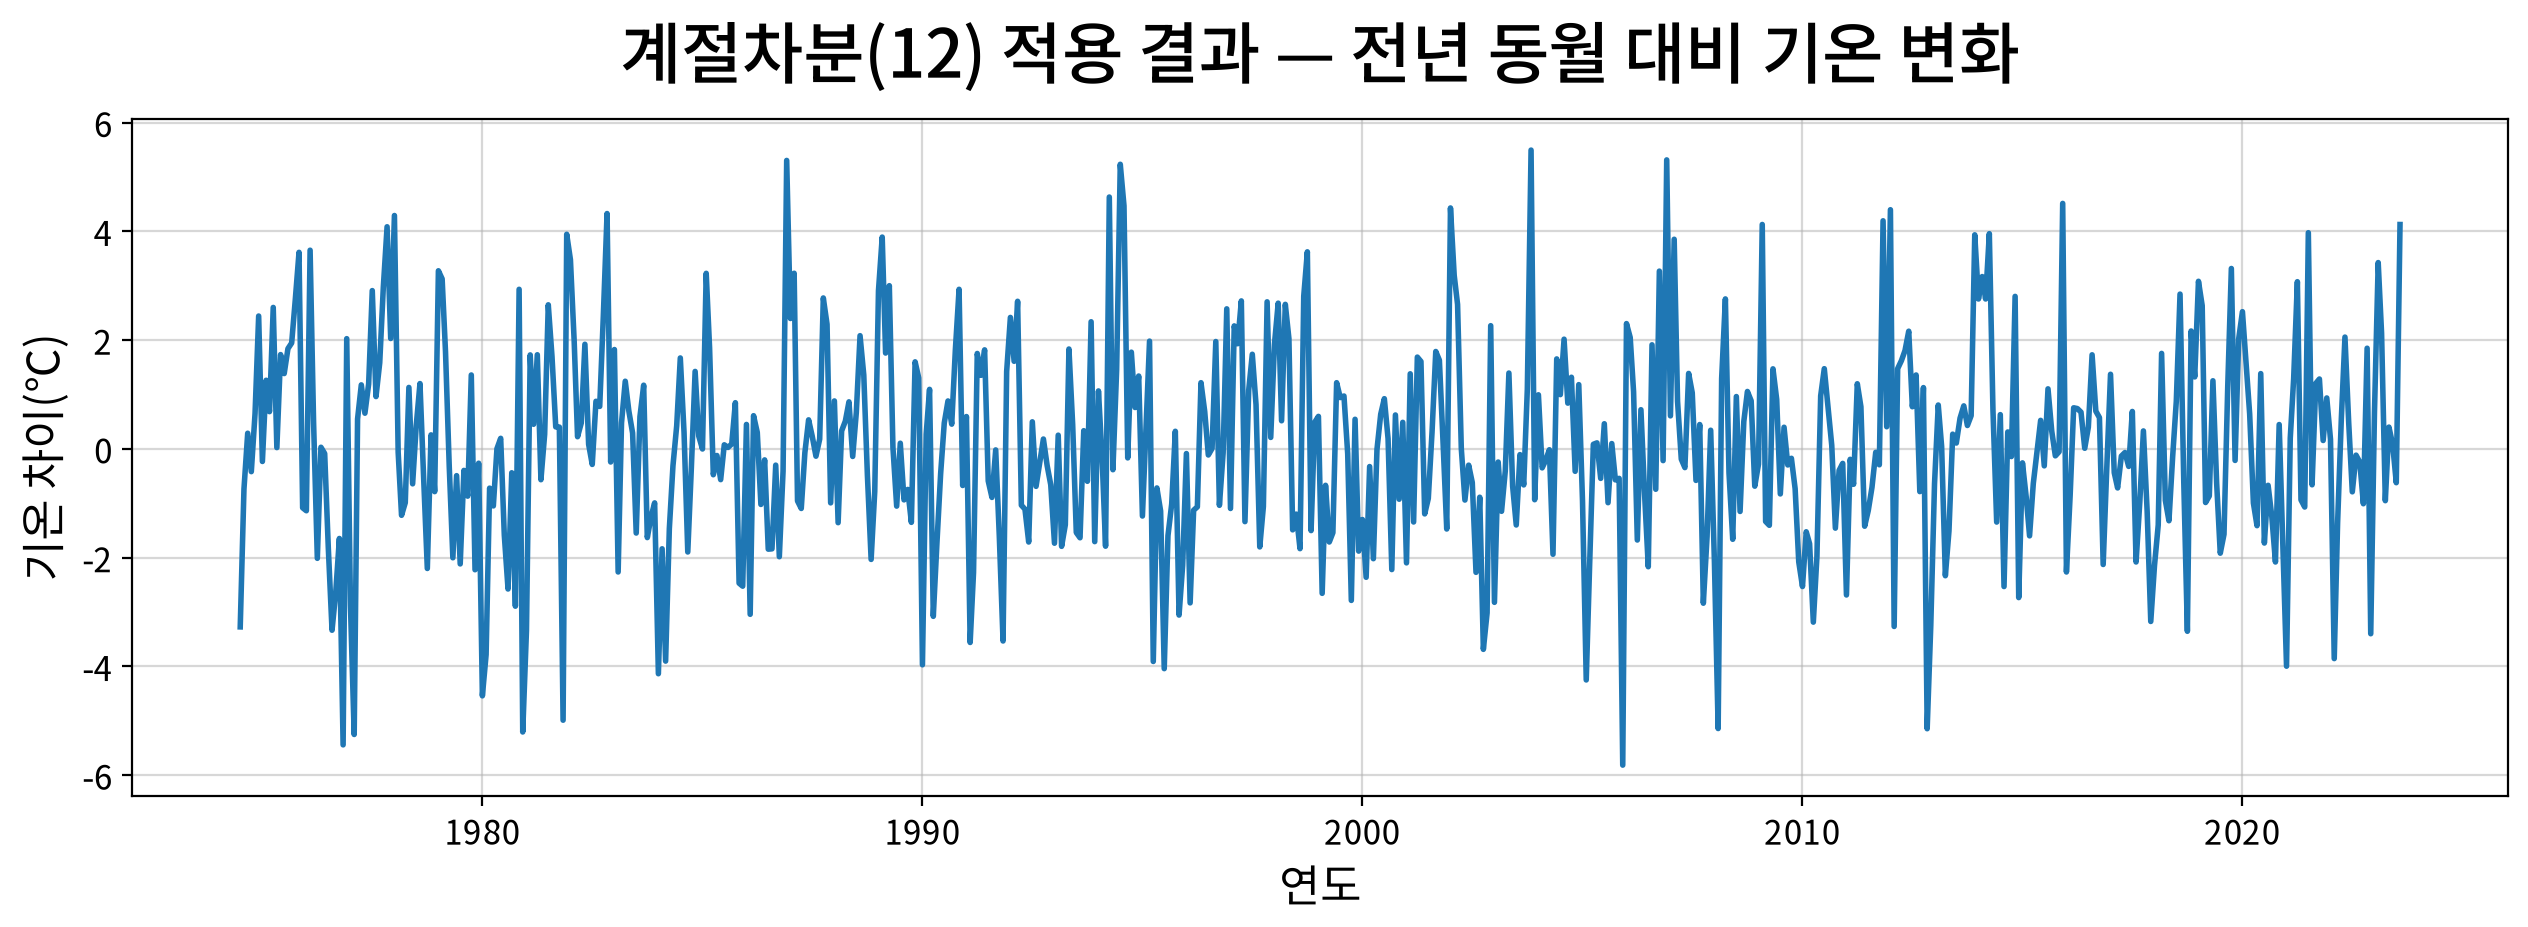

In [15]:
my_plot.lineplot(x=final.index, y=final,
                 title="계절차분(12) 적용 결과 — 전년 동월 대비 기온 변화",
                 xlabel="연도", ylabel="기온 차이(℃)",
                 width=1280, height=480)

#### 💡 인사이트

- **0을 중심으로 위아래로 흔들린다.** 산과 골의 반복이 사라졌다.
- 세로 폭이 ±5℃ 안쪽으로 줄었다. 원본의 −7℃ ~ +30℃ 범위와 비교하면 확연하다.

> 계절차분은 **"작년 같은 달과 비교해 몇 도 차이 나는가"** 를 계산한 것이다.
> 기온이 계절을 따라 움직이는 부분은 서로 상쇄되고, **그해에만 일어난 변화**만 남는다.

## #05. 정답

> 총 **1번**의 변환
> $d = 0$, $D = 1$, $s = 12$

| 기호 | 값 | 의미 |
|---|---|---|
| $d$ | **0** | 일반차분 횟수 — 추세가 없어 필요 없다 |
| $D$ | **1** | 계절차분 횟수 — 한 번으로 충분하다 |
| $s$ | **12** | 계절 주기 — 월간 데이터의 1년 |